In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [9]:
df = pd.read_csv("Mall_Customers.csv")

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [7]:
print(df.shape)

(200, 5)


In [10]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None


In [11]:
print(df.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [12]:
print(df.isnull().sum())


CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [13]:
print(df.duplicated().sum())

0


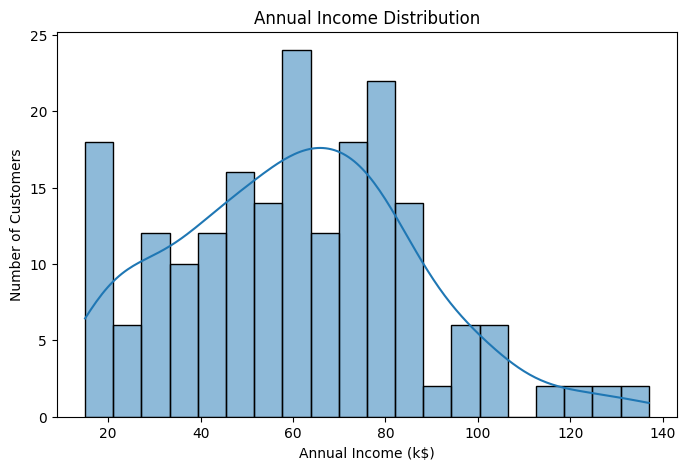

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Annual Income (k$)"], bins=20, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.show()

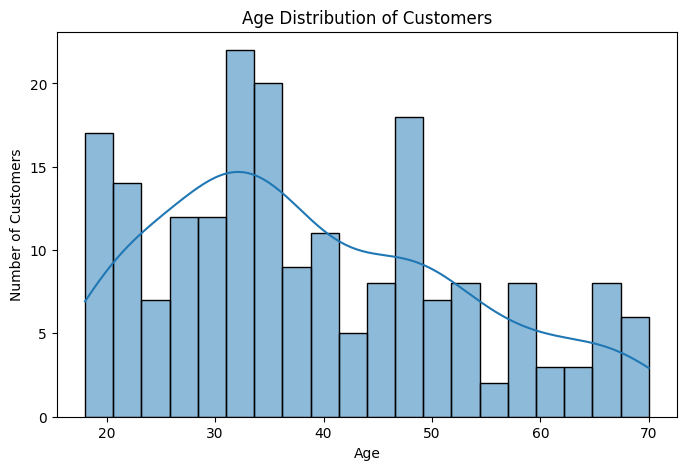

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

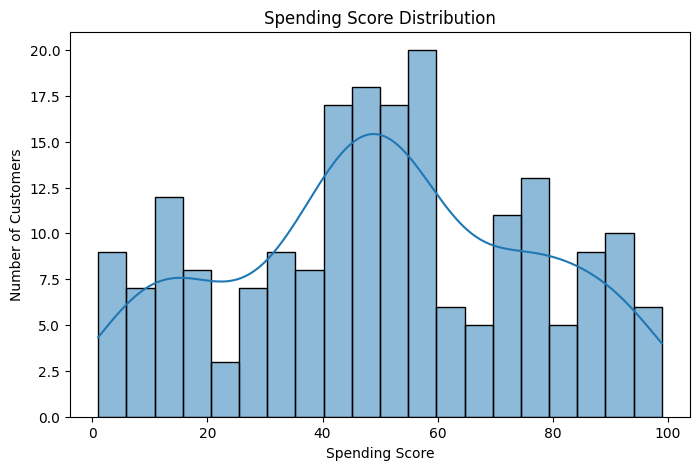

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.show()

In [18]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


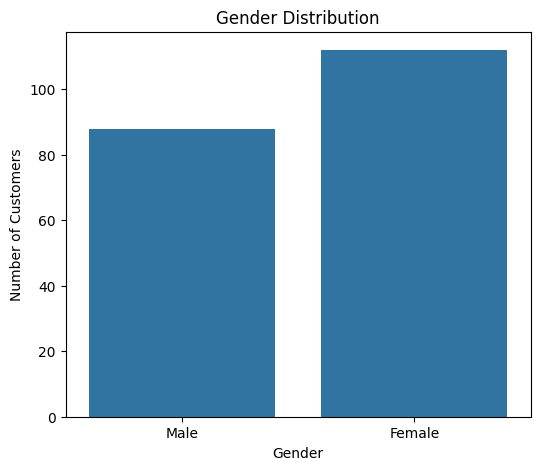

In [20]:
plt.figure(figsize=(6, 5))

sns.countplot(x="Genre", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

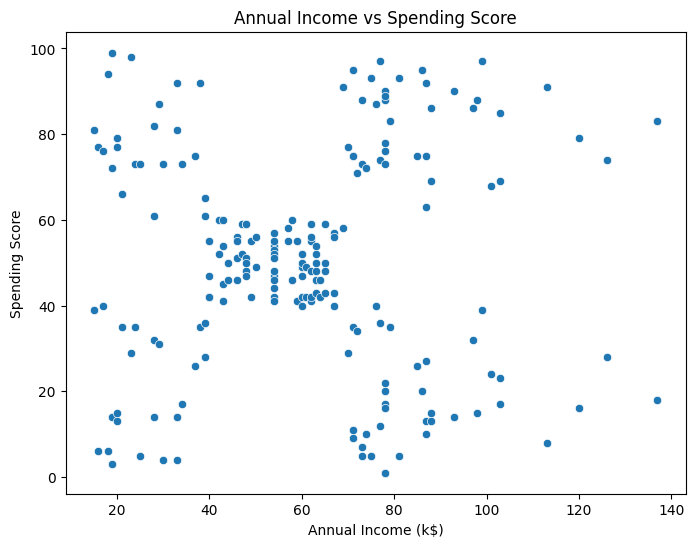

In [21]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    data=df
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

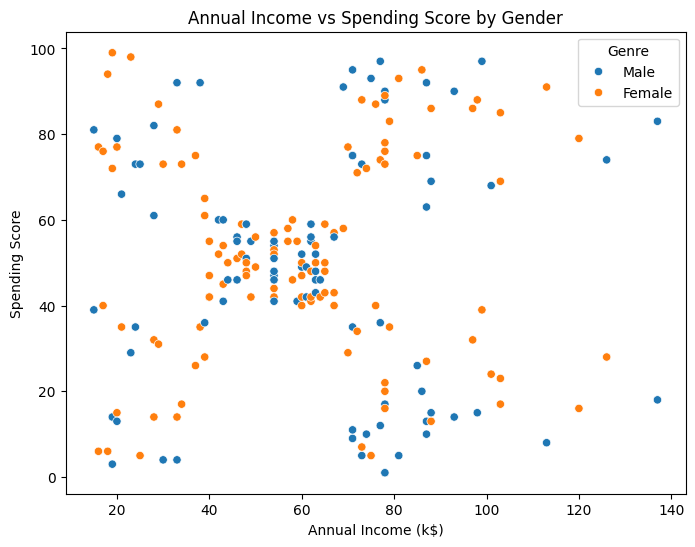

In [23]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Genre",
    data=df
)

plt.title("Annual Income vs Spending Score by Gender")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

In [24]:
numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

print(correlation)

                        CustomerID       Age  Annual Income (k$)  \
CustomerID                1.000000 -0.026763            0.977548   
Age                      -0.026763  1.000000           -0.012398   
Annual Income (k$)        0.977548 -0.012398            1.000000   
Spending Score (1-100)    0.013835 -0.327227            0.009903   

                        Spending Score (1-100)  
CustomerID                            0.013835  
Age                                  -0.327227  
Annual Income (k$)                    0.009903  
Spending Score (1-100)                1.000000  


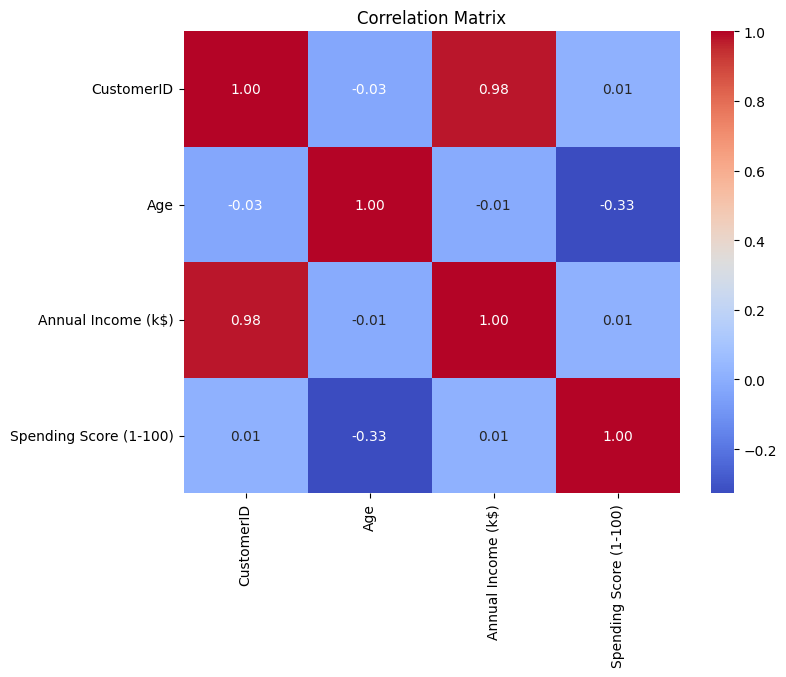

In [25]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [26]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [27]:
print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [28]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

print(wcss)

[269981.28, 181363.59595959593, 106348.37306211119, 73679.78903948834, 44448.45544793371, 37233.814510710006, 30241.34361793659, 25036.41760403398, 21916.794789843727, 20072.070939404006]


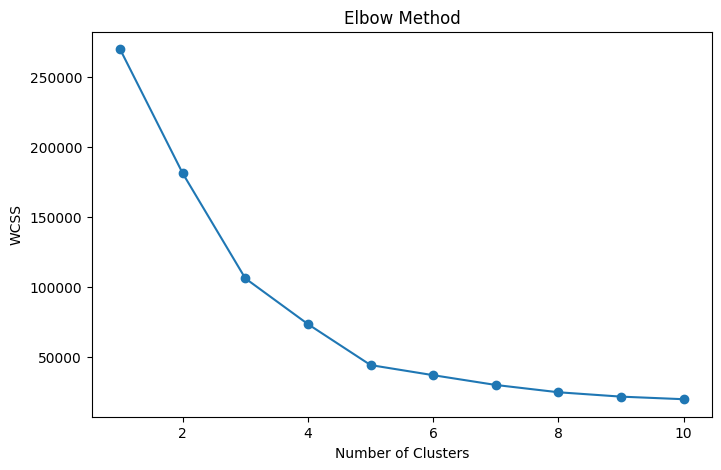

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [30]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

y_kmeans = kmeans.fit_predict(X)

print(y_kmeans)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [51]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")

print("K-Means model saved successfully!")

K-Means model saved successfully!


In [31]:
df["Cluster"] = y_kmeans

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


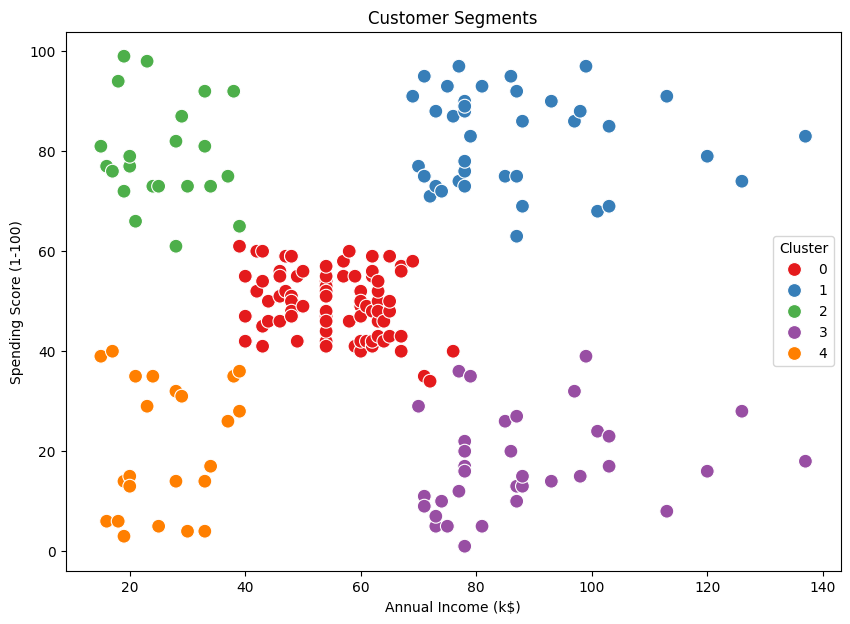

In [32]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    data=df,
    palette="Set1",
    s=100
)

plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")

plt.show()

In [33]:
cluster_summary = df.groupby("Cluster").agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean"
}).round(2)

print(cluster_summary)

           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        42.72               55.30                   49.52
1        32.69               86.54                   82.13
2        25.27               25.73                   79.36
3        41.11               88.20                   17.11
4        45.22               26.30                   20.91


In [34]:
cluster_count = df["Cluster"].value_counts().sort_index()

print(cluster_count)

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [35]:
cluster_summary.sort_values(
    by="Spending Score (1-100)",
    ascending=False
)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
1,32.69,86.54,82.13
2,25.27,25.73,79.36
0,42.72,55.30,49.52
4,45.22,26.30,20.91
3,41.11,88.20,17.11


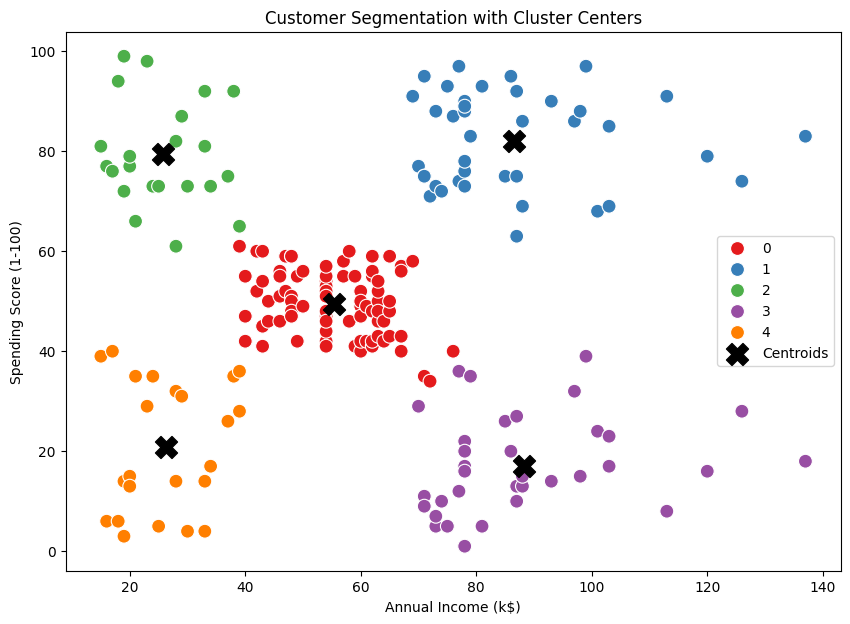

In [36]:
centers = kmeans.cluster_centers_

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    data=df,
    palette="Set1",
    s=100
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="black",
    s=250,
    marker="X",
    label="Centroids"
)

plt.title("Customer Segmentation with Cluster Centers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()

In [38]:
segment_names = {
    0: "Average Customers",
    1: "Premium Customers",
    2: "Young High-Spenders",
    3: "High-Income Low-Spenders",
    4: "Low-Value Customers"
}

df["Customer Segment"] = df["Cluster"].map(segment_names)

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster     Customer Segment  
0        4  Low-Value Customers  
1        2  Young High-Spenders  
2        4  Low-Value Customers  
3        2  Young High-Spenders  
4        4  Low-Value Customers  


In [39]:
print(df["Customer Segment"].value_counts())

Customer Segment
Average Customers           81
Premium Customers           39
High-Income Low-Spenders    35
Low-Value Customers         23
Young High-Spenders         22
Name: count, dtype: int64


In [40]:
final_summary = df.groupby("Customer Segment").agg(
    Customers=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending=("Spending Score (1-100)", "mean")
).round(2)

print(final_summary)

                          Customers  Average_Age  Average_Income  \
Customer Segment                                                   
Average Customers                81        42.72           55.30   
High-Income Low-Spenders         35        41.11           88.20   
Low-Value Customers              23        45.22           26.30   
Premium Customers                39        32.69           86.54   
Young High-Spenders              22        25.27           25.73   

                          Average_Spending  
Customer Segment                            
Average Customers                    49.52  
High-Income Low-Spenders             17.11  
Low-Value Customers                  20.91  
Premium Customers                    82.13  
Young High-Spenders                  79.36  


In [41]:
recommendations = {
    "Premium Customers": "Offer premium products, loyalty rewards and exclusive deals.",
    "Young High-Spenders": "Target with trendy products, discounts and social-media campaigns.",
    "High-Income Low-Spenders": "Use personalized offers to increase their spending.",
    "Low-Value Customers": "Offer affordable products and basic promotional campaigns.",
    "Average Customers": "Use general promotions and product recommendations."
}

df["Recommendation"] = df["Customer Segment"].map(recommendations)

print(df[[
    "CustomerID",
    "Customer Segment",
    "Recommendation"
]].head(10))

   CustomerID     Customer Segment  \
0           1  Low-Value Customers   
1           2  Young High-Spenders   
2           3  Low-Value Customers   
3           4  Young High-Spenders   
4           5  Low-Value Customers   
5           6  Young High-Spenders   
6           7  Low-Value Customers   
7           8  Young High-Spenders   
8           9  Low-Value Customers   
9          10  Young High-Spenders   

                                      Recommendation  
0  Offer affordable products and basic promotiona...  
1  Target with trendy products, discounts and soc...  
2  Offer affordable products and basic promotiona...  
3  Target with trendy products, discounts and soc...  
4  Offer affordable products and basic promotiona...  
5  Target with trendy products, discounts and soc...  
6  Offer affordable products and basic promotiona...  
7  Target with trendy products, discounts and soc...  
8  Offer affordable products and basic promotiona...  
9  Target with trendy products,

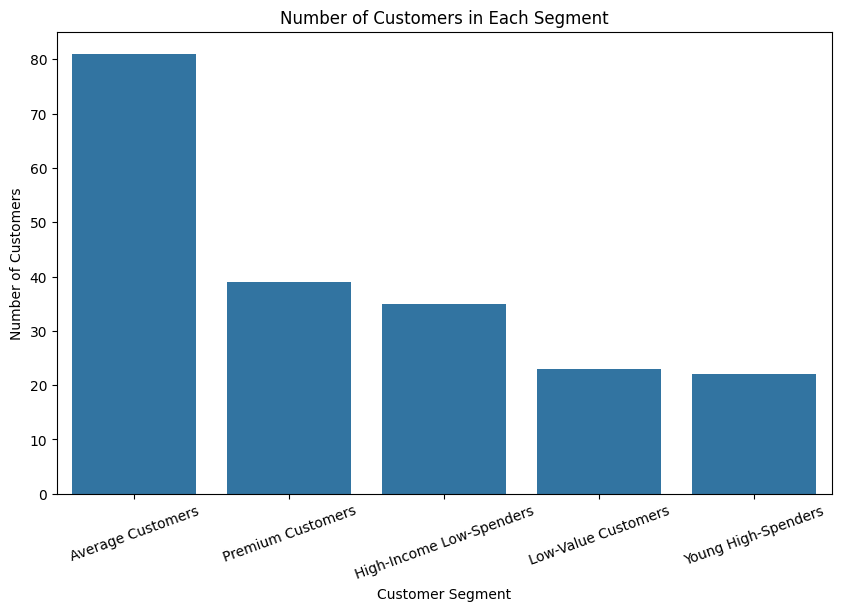

In [42]:
plt.figure(figsize=(10, 6))

sns.countplot(
    x="Customer Segment",
    data=df,
    order=df["Customer Segment"].value_counts().index
)

plt.title("Number of Customers in Each Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

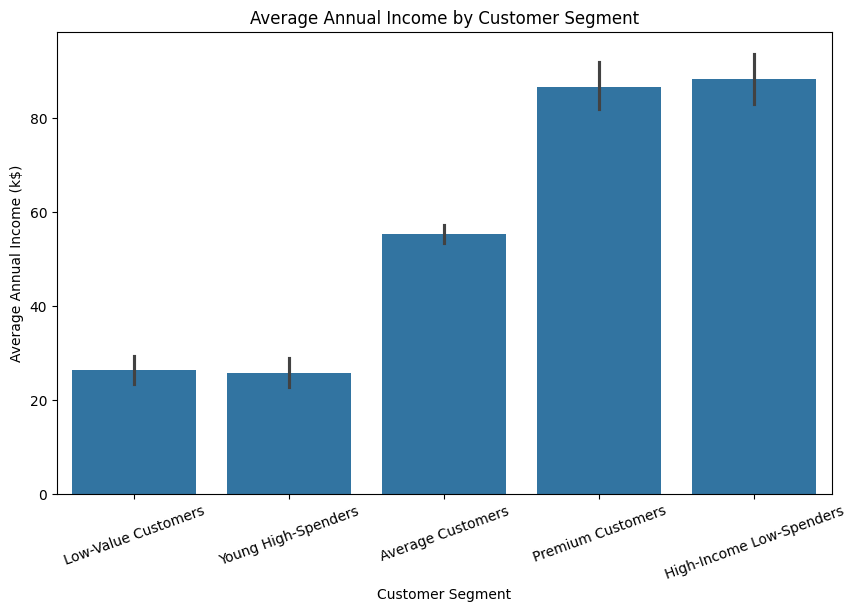

In [43]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Customer Segment",
    y="Annual Income (k$)",
    data=df
)

plt.title("Average Annual Income by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Annual Income (k$)")
plt.xticks(rotation=20)

plt.show()

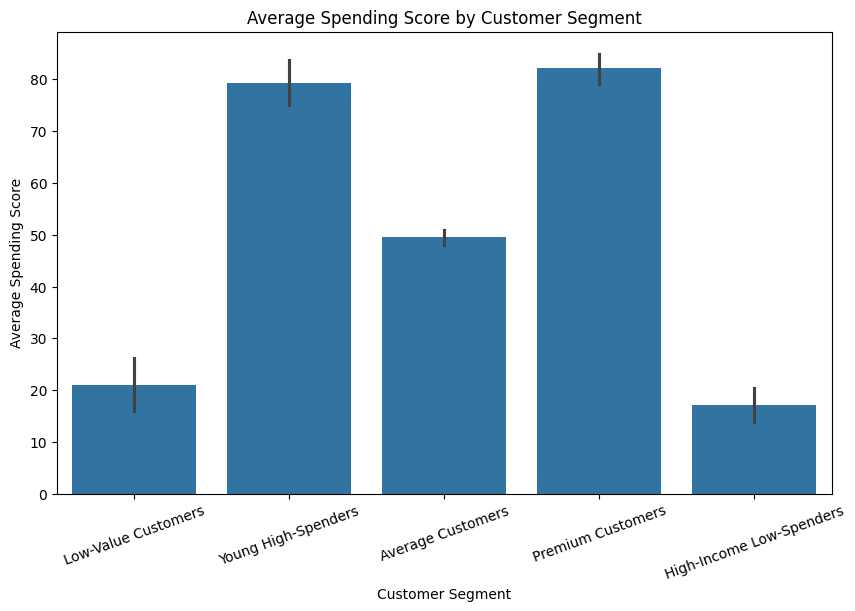

In [44]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Customer Segment",
    y="Spending Score (1-100)",
    data=df
)

plt.title("Average Spending Score by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Spending Score")
plt.xticks(rotation=20)

plt.show()

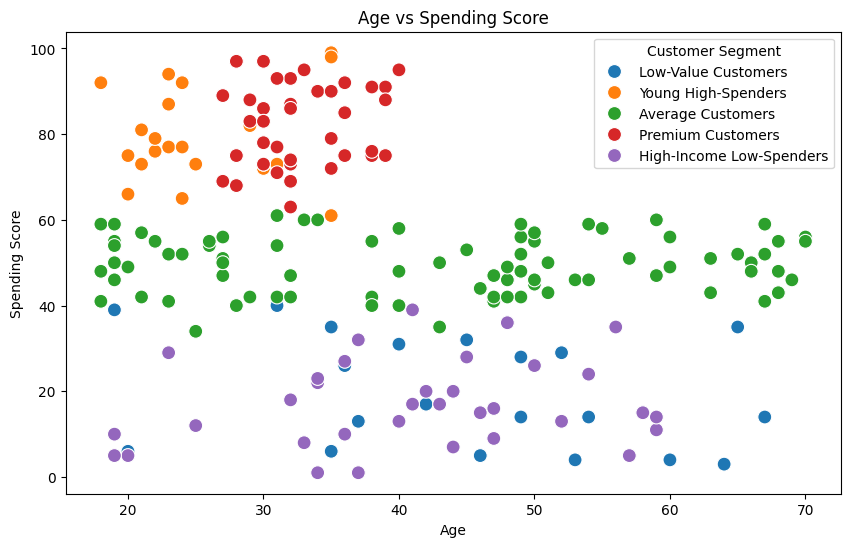

In [45]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="Age",
    y="Spending Score (1-100)",
    hue="Customer Segment",
    data=df,
    s=100
)

plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")

plt.show()

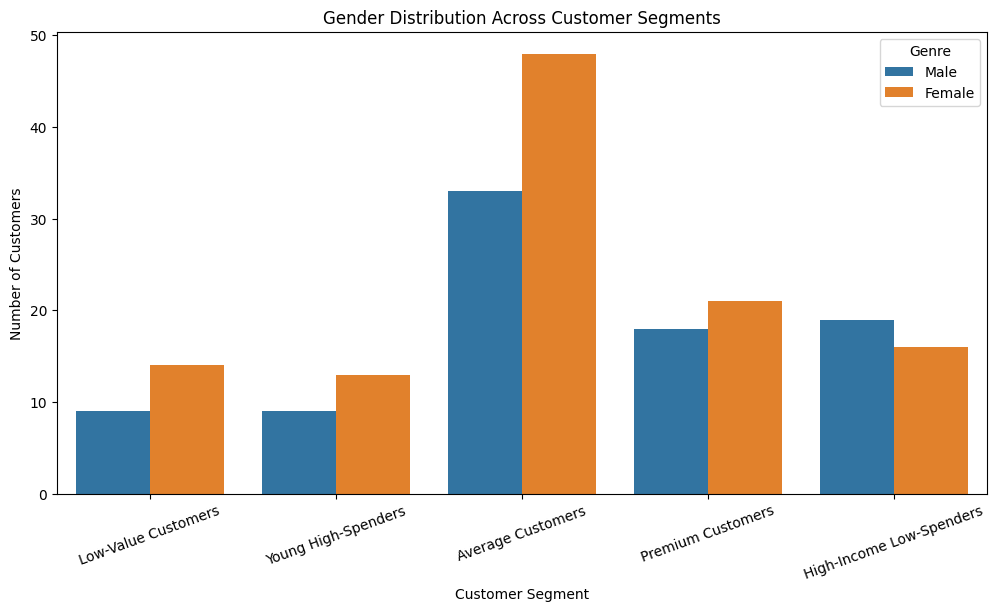

In [47]:
plt.figure(figsize=(12, 6))

sns.countplot(
    x="Customer Segment",
    hue="Genre",
    data=df
)

plt.title("Gender Distribution Across Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

In [48]:
final_summary = df.groupby("Customer Segment").agg(
    Customers=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending=("Spending Score (1-100)", "mean")
).round(2)

final_summary = final_summary.sort_values(
    "Average_Spending",
    ascending=False
)

print(final_summary)

                          Customers  Average_Age  Average_Income  \
Customer Segment                                                   
Premium Customers                39        32.69           86.54   
Young High-Spenders              22        25.27           25.73   
Average Customers                81        42.72           55.30   
Low-Value Customers              23        45.22           26.30   
High-Income Low-Spenders         35        41.11           88.20   

                          Average_Spending  
Customer Segment                            
Premium Customers                    82.13  
Young High-Spenders                  79.36  
Average Customers                    49.52  
Low-Value Customers                  20.91  
High-Income Low-Spenders             17.11  


In [49]:
df.to_csv("customer_segments.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!
